# 03 — Análise de Vendas
## LH Nautical | Camada Gold

**Objetivo:** Extrair insights de negócio a partir da tabela `fato_vendas`.

**Perguntas respondidas:**
1. Qual é o faturamento total e a margem do período?
2. Como evoluiu o faturamento mês a mês?
3. Qual canal vende mais e qual tem melhor margem?
4. Quais produtos geram mais receita? E mais prejuízo?
5. Existe sazonalidade? Qual o melhor dia da semana?

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from src.analysis.sales_analysis import (
    faturamento_total, faturamento_mensal, ticket_medio,
    margem_por_produto, produtos_com_prejuizo, ranking_produtos,
    vendas_por_dia_semana, analise_sazonalidade, analise_por_canal,
    gerar_resumo_executivo,
)

pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

AZUL_LH    = '#1565C0'
VERDE_LH   = '#2E7D32'
LARANJA_LH = '#E65100'
CINZA_LH   = '#546E7A'

# Carrega tabela Gold
fato     = pd.read_parquet('../data/gold/fato_vendas.parquet')
dim_prod = pd.read_parquet('../data/gold/dim_produtos.parquet')
print(f'fato_vendas : {fato.shape[0]:,} linhas x {fato.shape[1]} colunas')
print(f'dim_produtos: {dim_prod.shape[0]:,} produtos')

fato_vendas : 9,895 linhas x 18 colunas
dim_produtos: 150 produtos


---
## 1. Resumo Executivo — KPIs do Período

In [2]:
gerar_resumo_executivo(fato)


  RESUMO EXECUTIVO — LH Nautical
  Receita Total (líquida): R$ 2,610,279,510.70
  Lucro Bruto:             R$ 99,602,307.41
  Margem Média:                    3.6%
  Total de Pedidos:               9,895
  Itens Vendidos:                79,311
  Ticket Médio/Pedido:     R$   263,797.83
  Ticket Médio/Cliente:    R$ 53,271,010.42



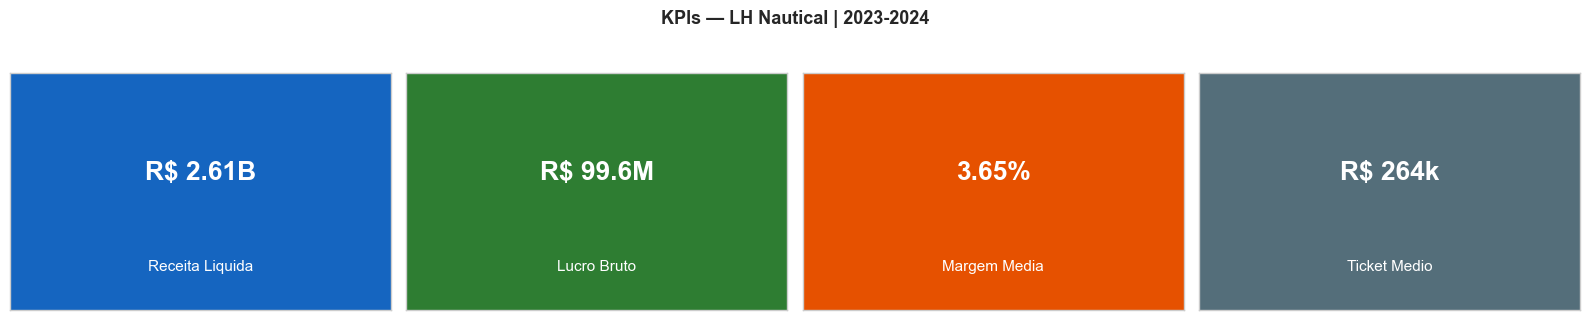

In [3]:
# KPIs como cards visuais
kpis   = faturamento_total(fato)
ticket = ticket_medio(fato)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
metricas = [
    ('Receita Liquida',  f'R$ {kpis["receita_liquida"]/1e9:.2f}B',  AZUL_LH),
    ('Lucro Bruto',      f'R$ {kpis["lucro_bruto"]/1e6:.1f}M',      VERDE_LH),
    ('Margem Media',     f'{kpis["margem_media_pct"]}%',             LARANJA_LH),
    ('Ticket Medio',     f'R$ {ticket["ticket_medio_transacao"]/1e3:.0f}k', CINZA_LH),
]

for ax, (titulo, valor, cor) in zip(axes, metricas):
    ax.set_facecolor(cor)
    ax.text(0.5, 0.58, valor, transform=ax.transAxes,
            fontsize=19, fontweight='bold', color='white', ha='center', va='center')
    ax.text(0.5, 0.18, titulo, transform=ax.transAxes,
            fontsize=11, color='white', ha='center', va='center')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('KPIs — LH Nautical | 2023-2024', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 2. Evolução Mensal do Faturamento

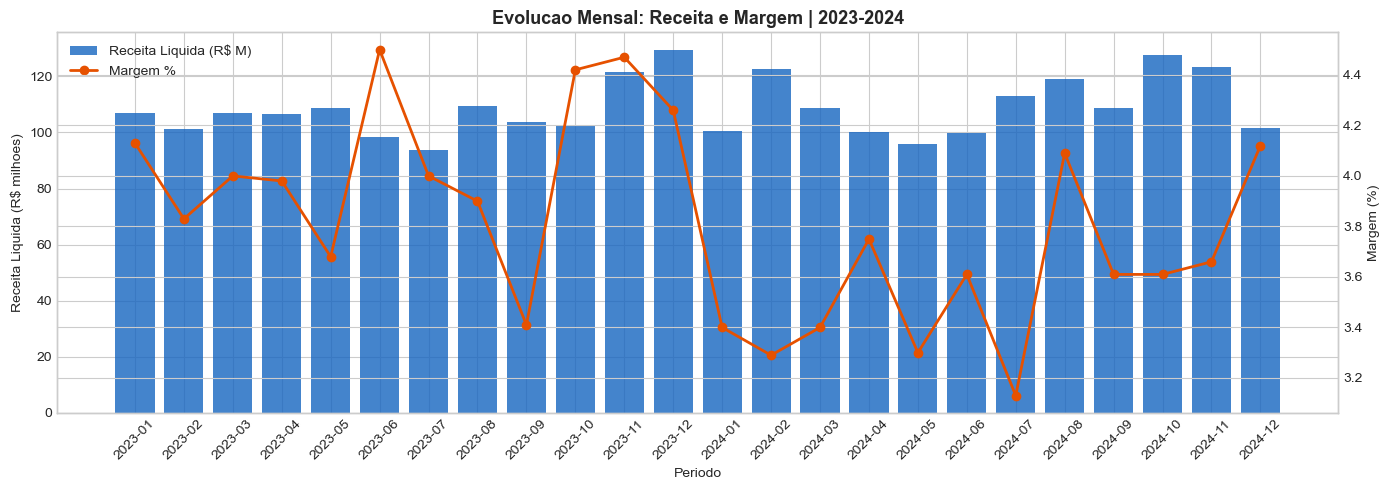


Comparativo 2023 vs 2024:


,receita_liquida,lucro_bruto,num_transacoes
ano,,,
2023,"1,288,827,294.55","52,269,138.64",4991
2024,"1,321,452,216.15","47,333,168.77",4904


In [4]:
mensal = faturamento_mensal(fato)
mensal['periodo'] = mensal['ano'].astype(str) + '-' + mensal['mes'].astype(str).str.zfill(2)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(mensal['periodo'], mensal['receita_liquida'] / 1e6,
        color=AZUL_LH, alpha=0.8, label='Receita Liquida (R$ M)')

ax2 = ax1.twinx()
ax2.plot(mensal['periodo'], mensal['margem_pct'],
         color=LARANJA_LH, marker='o', linewidth=2, label='Margem %')

ax1.set_title('Evolucao Mensal: Receita e Margem | 2023-2024', fontweight='bold', fontsize=13)
ax1.set_xlabel('Periodo')
ax1.set_ylabel('Receita Liquida (R$ milhoes)')
ax2.set_ylabel('Margem (%)')
ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print('\nComparativo 2023 vs 2024:')
display(mensal.groupby('ano').agg(
    receita_liquida=('receita_liquida', 'sum'),
    lucro_bruto=('lucro_bruto', 'sum'),
    num_transacoes=('num_transacoes', 'sum'),
).round(2))

---
## 3. Performance por Canal de Venda

,canal_venda,receita_liquida,lucro_bruto,num_transacoes,ticket_medio,margem_pct,participacao_receita_pct
0,ecommerce,"2,559,155,778.35","97,903,745.31",9686,"264,211.83",3.83,98.04
1,loja_fisica,"51,123,732.35","1,698,562.10",209,"244,611.16",3.32,1.96


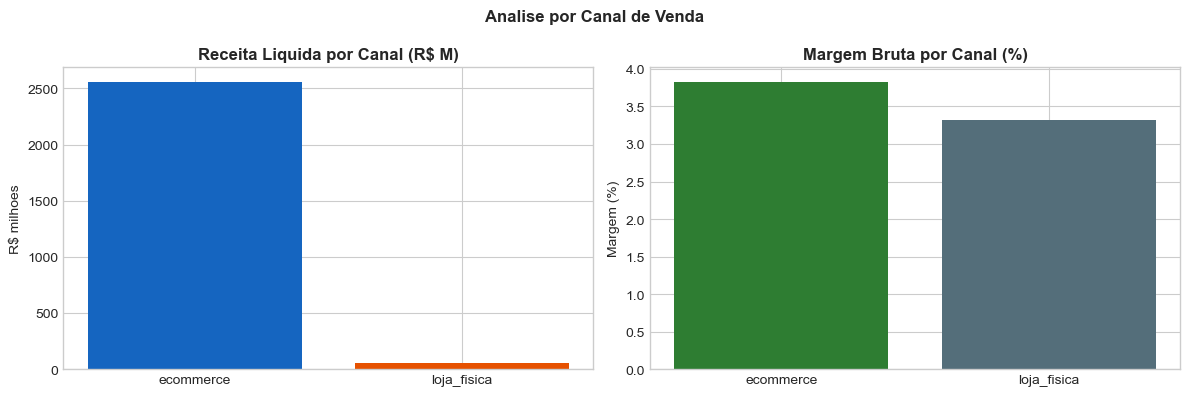

In [5]:
canal = analise_por_canal(fato)
display(canal)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(canal['canal_venda'], canal['receita_liquida'] / 1e6,
            color=[AZUL_LH, LARANJA_LH])
axes[0].set_title('Receita Liquida por Canal (R$ M)', fontweight='bold')
axes[0].set_ylabel('R$ milhoes')

axes[1].bar(canal['canal_venda'], canal['margem_pct'],
            color=[VERDE_LH, CINZA_LH])
axes[1].set_title('Margem Bruta por Canal (%)', fontweight='bold')
axes[1].set_ylabel('Margem (%)')

plt.suptitle('Analise por Canal de Venda', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Ranking de Produtos

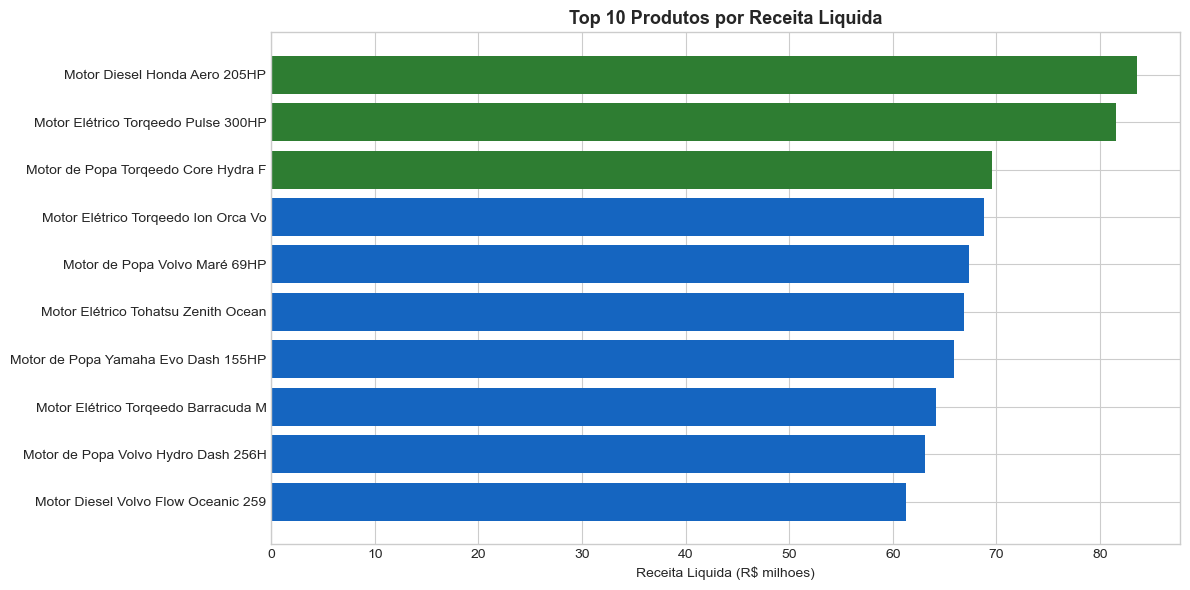

Top 10 com detalhes:


,nome_produto,categoria,receita_liquida
0,Motor Diesel Honda Aero 205HP,Propulsão,"83,539,339.40"
1,Motor Elétrico Torqeedo Pulse 300HP,Propulsão,"81,567,066.65"
2,Motor de Popa Torqeedo Core Hydra Flux 162HP,Propulsão,"69,554,254.80"
3,Motor Elétrico Torqeedo Ion Orca Vox 186HP,Propulsão,"68,817,185.90"
4,Motor de Popa Volvo Maré 69HP,Propulsão,"67,332,086.05"
5,Motor Elétrico Tohatsu Zenith Oceanic 113HP,Propulsão,"66,829,268.70"
6,Motor de Popa Yamaha Evo Dash 155HP,Propulsão,"65,859,716.10"
7,Motor Elétrico Torqeedo Barracuda Magnum Helix...,Propulsão,"64,195,127.60"
8,Motor de Popa Volvo Hydro Dash 256HP,Propulsão,"63,057,815.65"
9,Motor Diesel Volvo Flow Oceanic 259HP,Propulsão,"61,224,375.00"


In [6]:
top_produtos = ranking_produtos(fato, criterio='receita', top_n=10)
top_produtos = top_produtos.merge(
    dim_prod[['id_produto','nome_produto','categoria']], on='id_produto'
)

fig, ax = plt.subplots(figsize=(12, 6))
cores = [VERDE_LH if i < 3 else AZUL_LH for i in range(len(top_produtos))]
ax.barh(top_produtos['nome_produto'].str[:35], top_produtos['receita'] / 1e6, color=cores)
ax.set_title('Top 10 Produtos por Receita Liquida', fontweight='bold', fontsize=13)
ax.set_xlabel('Receita Liquida (R$ milhoes)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 com detalhes:')
display(top_produtos[['nome_produto','categoria','receita']].rename(
    columns={'receita':'receita_liquida'}
))

---
## 5. Produtos com Prejuízo — Alerta de Gestão

In [7]:
prejuizo = produtos_com_prejuizo(fato)

if not prejuizo.empty:
    print(f'[! ALERTA] {len(prejuizo)} produto(s) com margem negativa acumulada:')
    prejuizo_nomes = prejuizo.merge(dim_prod[['id_produto','nome_produto','categoria']], on='id_produto')
    display(prejuizo_nomes[['nome_produto','categoria','receita_liquida','lucro_bruto','margem_pct']]
            .sort_values('margem_pct'))

    # Impacto financeiro
    perda = prejuizo['lucro_bruto'].sum()
    print(f'\nPerda acumulada por produtos deficitarios: R$ {perda:,.2f}')
else:
    print('[OK] Nenhum produto com prejuizo acumulado detectado.')

[! ALERTA] 30 produto(s) com margem negativa acumulada:


,nome_produto,categoria,receita_liquida,lucro_bruto,margem_pct
12,Transponder Lowrance Axis,Eletrônicos,"2,810,048.65","-296,060.57",-10.54
3,Motor de Popa Tohatsu Boost Swift 126HP,Propulsão,"27,227,868.90","-2,539,188.90",-9.33
14,Boia de Arqueamento Bruce Titan,Ancoragem,"2,164,907.10","-167,744.82",-7.75
21,Boia de Arqueamento Bruce Tidal Marlin,Ancoragem,"781,887.35","-60,340.95",-7.72
16,Âncora Bruce Aqua,Ancoragem,"1,668,115.45","-118,656.52",-7.11
0,Motor Elétrico Tohatsu Zenith Oceanic 113HP,Propulsão,"66,829,268.70","-4,580,502.48",-6.85
6,Transponder AIS Boost,Eletrônicos,"19,077,841.00","-1,292,015.36",-6.77
5,Motor Diesel Tohatsu Kinetic Poseidon 113HP,Propulsão,"22,442,621.25","-1,480,210.89",-6.60
4,Motor Elétrico Volvo Boost 225HP,Propulsão,"27,930,725.05","-1,819,682.78",-6.51
18,Boia de Arqueamento Danforth Flux Tidal,Ancoragem,"1,739,699.50","-110,797.30",-6.37



Perda acumulada por produtos deficitarios: R$ -22,265,428.23


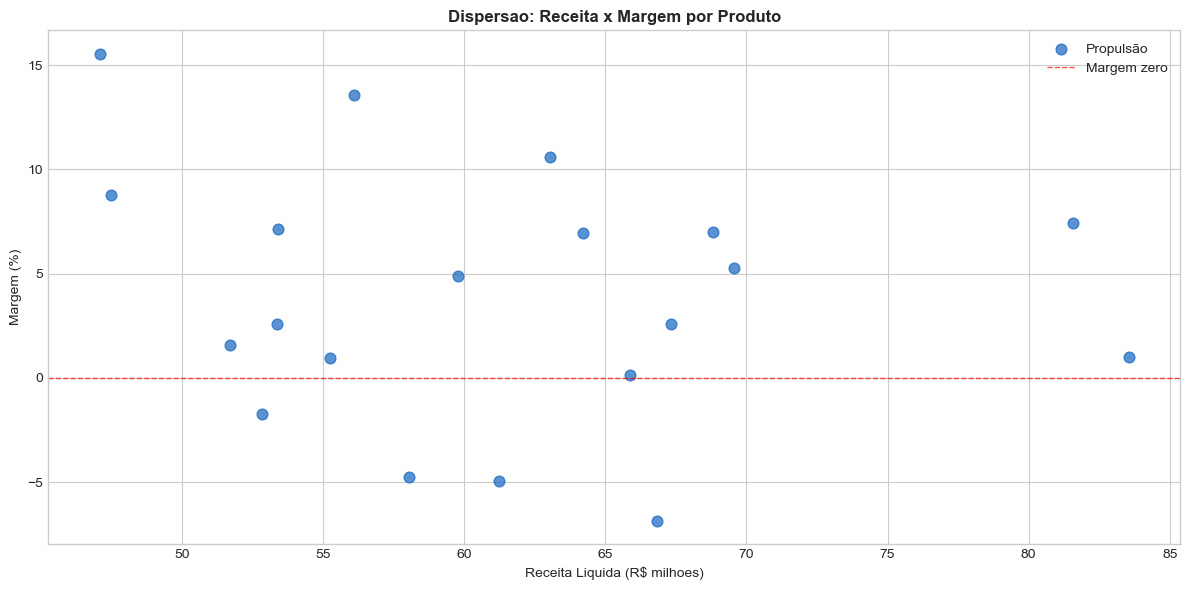

In [8]:
# Visualizacao: dispersao margem x receita por produto
mp = margem_por_produto(fato)
mp = mp.merge(dim_prod[['id_produto','nome_produto','categoria']], on='id_produto')

fig, ax = plt.subplots(figsize=(12, 6))

cats = mp['categoria'].unique()
cores_cat = dict(zip(cats, [AZUL_LH, LARANJA_LH, VERDE_LH]))

for cat in cats:
    sub = mp[mp['categoria'] == cat]
    ax.scatter(sub['receita_liquida'] / 1e6, sub['margem_pct'],
               label=cat, alpha=0.7, s=60, color=cores_cat[cat])

ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Margem zero')
ax.set_xlabel('Receita Liquida (R$ milhoes)')
ax.set_ylabel('Margem (%)')
ax.set_title('Dispersao: Receita x Margem por Produto', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Sazonalidade e Dia da Semana

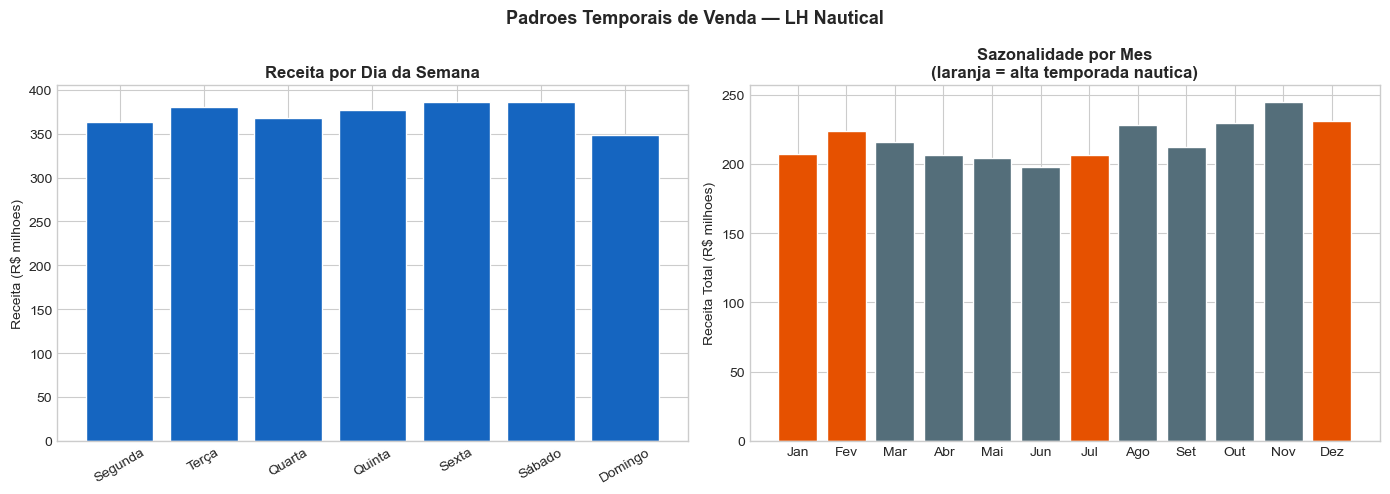

In [9]:
diasemana = vendas_por_dia_semana(fato)
sazonal   = analise_sazonalidade(fato)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dia da semana
dsw = diasemana.dropna(subset=['dia_semana_pt'])
axes[0].bar(dsw['dia_semana_pt'], dsw['receita_liquida'] / 1e6,
            color=AZUL_LH, edgecolor='white')
axes[0].set_title('Receita por Dia da Semana', fontweight='bold')
axes[0].set_ylabel('Receita (R$ milhoes)')
axes[0].tick_params(axis='x', rotation=30)

# Sazonalidade mensal
sazonal_agg = sazonal.groupby('mes')['receita_total'].sum()
meses_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
cores_m = [LARANJA_LH if m in [12, 1, 2, 7] else CINZA_LH for m in sazonal_agg.index]
axes[1].bar([meses_pt[m-1] for m in sazonal_agg.index], sazonal_agg.values / 1e6,
            color=cores_m, edgecolor='white')
axes[1].set_title('Sazonalidade por Mes\n(laranja = alta temporada nautica)', fontweight='bold')
axes[1].set_ylabel('Receita Total (R$ milhoes)')

plt.suptitle('Padroes Temporais de Venda — LH Nautical', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Insights Executivos

**1. Margem sob pressão:** Margem média de 3,6% com 30 produtos vendidos abaixo do custo.
Revisão urgente de precificação para os itens deficitários.

**2. E-commerce dominante:** 98% da receita via e-commerce, apenas 2% loja física.
Investimento em UX digital tem ROI muito superior a expansão física.

**3. Receita distribuída na semana:** Sem concentração em dias específicos — 
operação estável, sem gargalos de pico.

**4. Sazonalidade moderada:** Variações mensais existem mas sem pico extremo —
planejamento de estoque pode ser uniforme com reforço em dez/jan/jul.

> **Próximo passo:** `04_clientes.ipynb` — análise de segmentação e valor de cliente.